# Deep Learning
# BiLSTM with Attention and GloVe

In [1]:
import os
import re
import json
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

Config

In [4]:
SEED = 42

# Data

TEXT_COL = "text"
LABEL_COL = "label"

# Embeddings
GLOVE_DIM = 100
GLOVE_PATH = "../data/Glove/glove.6B.100d.txt"

# Vocabulary
MIN_WORD_FREQ = 2                     # similar to  min_df=2 from the TF-IDF 
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

# Sequence
MAX_LEN = None                        

# Model
HIDDEN_DIM = 128                      
NUM_LAYERS = 1
DROPOUT = 0.4
FREEZE_EMBEDDINGS = True

# Training
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MAX_EPOCHS = 20
PATIENCE = 3                          # early stopping on val F1
GRAD_CLIP = 5.0

# Artifacts
SAVE_DIR = "saved/bilstm"
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------------------------------------------------


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Device: {DEVICE}")
print(f"GloVe dimension: {GLOVE_DIM}")

Device: cpu
GloVe dimension: 100


In [5]:
import os
print(os.path.exists(GLOVE_PATH), GLOVE_PATH)

True ../data/Glove/glove.6B.100d.txt


In [6]:


TRAIN_PATH = "../data/processed/train.csv"   
VAL_PATH   = "../data/processed/val.csv"
TEST_PATH  = "../data/processed/test.csv"


def load_split(path, text_col, label_col):
    frame = pd.read_csv(path)
    frame[text_col] = frame[text_col].fillna("").astype(str)
    frame[label_col] = frame[label_col].astype(int)
    return frame


train_df = load_split(TRAIN_PATH, TEXT_COL, LABEL_COL)
val_df   = load_split(VAL_PATH,   TEXT_COL, LABEL_COL)
test_df  = load_split(TEST_PATH,  TEXT_COL, LABEL_COL)

for name, frame in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:<6} {len(frame):>7,} rows | {frame[LABEL_COL].mean():.4f} positive")

total_rows = len(train_df) + len(val_df) + len(test_df)
print(f"\nTotal: {total_rows:,}")

# Integrity check
train_texts = set(train_df[TEXT_COL])
val_texts   = set(val_df[TEXT_COL])
test_texts  = set(test_df[TEXT_COL])

print(f"Train∩Val overlap:  {len(train_texts & val_texts):,}")
print(f"Train∩Test overlap: {len(train_texts & test_texts):,}")
print(f"Val∩Test overlap:   {len(val_texts & test_texts):,}")

Train   14,441 rows | 0.3706 positive
Val      3,094 rows | 0.3704 positive
Test     3,095 rows | 0.3706 positive

Total: 20,630
Train∩Val overlap:  0
Train∩Test overlap: 0
Val∩Test overlap:   0


Token-length percentiles (train set):
  p50:    117
  p75:    200
  p90:    347
  p95:    813
  p97:    835
  p99:  2,100
  max:  4,566
 mean:  195.5


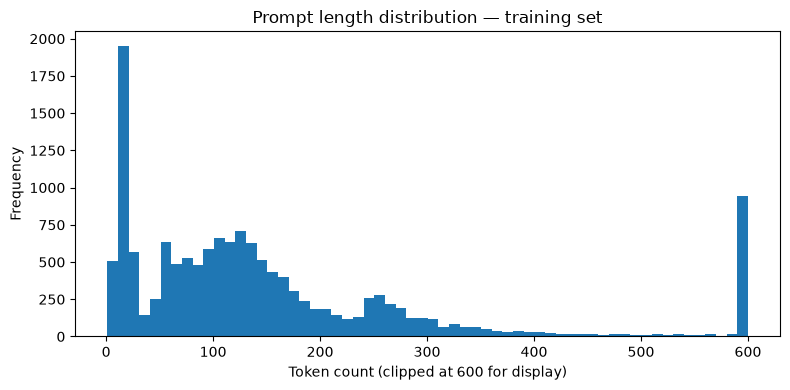

In [7]:
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+|[^\sA-Za-z0-9]")


def tokenize(text):
    """Lowercase + regex tokenizer that keeps punctuation as separate tokens."""
    return TOKEN_PATTERN.findall(text.lower())


train_tokens = [tokenize(t) for t in train_df[TEXT_COL]]
train_lengths = np.array([len(toks) for toks in train_tokens])

percentiles = [50, 75, 90, 95, 97, 99]
print("Token-length percentiles (train set):")
for p in percentiles:
    print(f"  p{p:>2}: {int(np.percentile(train_lengths, p)):>6,}")
print(f"  max: {train_lengths.max():>6,}")
print(f" mean: {train_lengths.mean():>6.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(train_lengths, 0, 600), bins=60)
ax.set_xlabel("Token count (clipped at 600 for display)")
ax.set_ylabel("Frequency")
ax.set_title("Prompt length distribution — training set")
plt.tight_layout()
plt.show()

Fix MAX_LEN

In [10]:
for candidate in [128, 256, 384, 512, 768, 1024]:
    cov_benign = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 0, "token_len"] <= candidate).mean()
    cov_malicious = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 1, "token_len"] <= candidate).mean()
    print(f"MAX_LEN = {candidate:>5}: benign {cov_benign:.2%} | malicious {cov_malicious:.2%}")

MAX_LEN =   128: benign 57.71% | malicious 51.76%
MAX_LEN =   256: benign 80.67% | malicious 84.38%
MAX_LEN =   384: benign 89.32% | malicious 94.08%
MAX_LEN =   512: benign 91.12% | malicious 95.57%
MAX_LEN =   768: benign 93.88% | malicious 96.38%
MAX_LEN =  1024: benign 97.59% | malicious 99.48%


In [ ]:
# Percentile-based candidate
p95_len = int(np.percentile(train_lengths, 95))
print(f"p95 token length: {p95_len}")


# coverage in particular improves substantially at 384 vs 256.
MAX_LEN = 384

coverage_overall = (train_lengths <= MAX_LEN).mean()
coverage_benign = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 0, "token_len"] <= MAX_LEN).mean()
coverage_malicious = (train_df_with_len.loc[train_df_with_len[LABEL_COL] == 1, "token_len"] <= MAX_LEN).mean()

print(f"MAX_LEN = {MAX_LEN}")
print(f"Overall coverage:   {coverage_overall:.2%}")
print(f"Benign coverage:    {coverage_benign:.2%}")
print(f"Malicious coverage: {coverage_malicious:.2%}")

p95 token length: 813
MAX_LEN = 384
Overall coverage:   91.08%
Benign coverage:    89.32%
Malicious coverage: 94.08%
